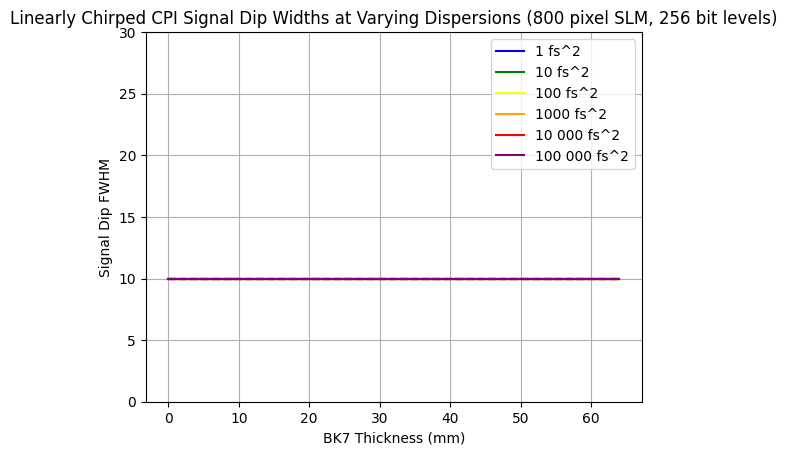

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import matplotlib.ticker as ticker
import os

#for each of linear, erf, super erf, want:
#one array for each of ideal and realistic at each c (so 12 total, 1 for each SLM type)

folder_name = "Realistic_Chirps_800px_256lv"
##these are for generating the dip plots further down
Ls = [0, 10000, 50000, 100000, 150000, 200000]
titles = [f'L = {Ls[0]}', f'L = {Ls[1]}', f'L = {Ls[2]}', f'L = {Ls[3]}', f'L = {Ls[4]}', f'L = {Ls[5]}']

Cs = [1, 10, 100, 1000, 10000, 100000]

realistic_1 = []
realistic_10 = []
realistic_100 = []
realistic_1000 = []
realistic_10k = []
realistic_100k = []

ideal_1 = []
ideal_10 = []
ideal_100 = []
ideal_1000 = []
ideal_10k = []
ideal_100k = []

os.makedirs(f"results/{folder_name}/plots", exist_ok=True)

f = open(f"./results/{folder_name}/plotting_params.txt", "r")
params = f.readlines()
f.close()

dispersion_type = params[0].rstrip()
tau_range = int(params[1])
max_L = int(params[2])
L_stepsize = int(params[3])
bit_levels = int(params[4])
num_pixels = int(params[5])

Lvals = np.arange(0, max_L, L_stepsize)
taus = np.arange(-tau_range, tau_range + 0.5, 0.5)

# --- Initial guesses ---
init_guess = [0, 0.0025, 0.9, 10]

def one_minus_gaussian(t, t_0, a1, a2, fwhm):
    return a1 - a2*np.exp(-4*np.log(2)*((t - t_0)**2)/fwhm**2)

def chisq(params, t, y):
    t0, a1, a2, fwhm = params
    model = one_minus_gaussian(t, t0, a1, a2, fwhm)
    return np.sum((y - model)**2)

def residuals(params, t, y):
    T0, a1, a2, sigma = params
    model = (a1 - a2 * np.exp(-4 * np.log(2) * (t - T0)**2 / sigma**2))
    return model - y

##not sure if i should normalize, then curve fit or the other way around

for L in Lvals:
    init_guess = [0, 0.00015*L, 0.9, 10]

    r_1 = np.loadtxt(f"./results/{folder_name}/linear/chirp_1/realistic/L{L}.txt")
    r_10 = np.loadtxt(f"./results/{folder_name}/linear/chirp_10/realistic/L{L}.txt")
    r_100 = np.loadtxt(f"./results/{folder_name}/linear/chirp_100/realistic/L{L}.txt")
    r_1000 = np.loadtxt(f"./results/{folder_name}/linear/chirp_1000/realistic/L{L}.txt")
    r_10k = np.loadtxt(f"./results/{folder_name}/linear/chirp_10000/realistic/L{L}.txt")
    r_100k = np.loadtxt(f"./results/{folder_name}/linear/chirp_100000/realistic/L{L}.txt")

    i_1 = np.loadtxt(f"./results/{folder_name}/linear/chirp_1/ideal/L{L}.txt")
    i_10 = np.loadtxt(f"./results/{folder_name}/linear/chirp_10/ideal/L{L}.txt")
    i_100 = np.loadtxt(f"./results/{folder_name}/linear/chirp_100/ideal/L{L}.txt")
    i_1000 = np.loadtxt(f"./results/{folder_name}/linear/chirp_1000/ideal/L{L}.txt")
    i_10k = np.loadtxt(f"./results/{folder_name}/linear/chirp_10000/ideal/L{L}.txt")
    i_100k = np.loadtxt(f"./results/{folder_name}/linear/chirp_100000/ideal/L{L}.txt")
    

    # --- Fit the data ---
    #pretty sure maggies code uses the LevenbergMarquardt method, at least for the 0 dispersion dip
    realistic_1.append(least_squares(residuals, init_guess, args=(taus, r_1), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    realistic_10.append(least_squares(residuals, init_guess, args=(taus, r_10), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    realistic_100.append(least_squares(residuals, init_guess, args=(taus, r_100), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    realistic_1000.append(least_squares(residuals, init_guess, args=(taus, r_1000), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    realistic_10k.append(least_squares(residuals, init_guess, args=(taus, r_10k), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    realistic_100k.append(least_squares(residuals, init_guess, args=(taus, r_100k), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])

    ideal_1.append(least_squares(residuals, init_guess, args=(taus, i_1), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    ideal_10.append(least_squares(residuals, init_guess, args=(taus, i_10), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    ideal_100.append(least_squares(residuals, init_guess, args=(taus, i_100), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    ideal_1000.append(least_squares(residuals, init_guess, args=(taus, i_1000), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    ideal_10k.append(least_squares(residuals, init_guess, args=(taus, i_10k), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    ideal_100k.append(least_squares(residuals, init_guess, args=(taus, i_100k), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])


plt.plot(Lvals, ideal_1, label = "1 fs^2", color = 'blue')
plt.plot(Lvals, realistic_1, color = 'blue', linestyle = 'dashed')

plt.plot(Lvals, ideal_10, label = "10 fs^2", color = 'green')
plt.plot(Lvals, realistic_10, color = 'green', linestyle = 'dashed')

plt.plot(Lvals, ideal_100, label = "100 fs^2", color = 'yellow')
plt.plot(Lvals, realistic_100, color = 'yellow', linestyle = 'dashed')

plt.plot(Lvals, ideal_1000, label = "1000 fs^2", color = 'orange')
plt.plot(Lvals, realistic_1000, color = 'orange', linestyle = 'dashed')

plt.plot(Lvals, ideal_10k, label = "10 000 fs^2", color = 'red')
plt.plot(Lvals, realistic_10k, color = 'red', linestyle = 'dashed')

plt.plot(Lvals, ideal_100k, label = "100 000 fs^2", color = 'purple')
plt.plot(Lvals, realistic_100k, color = 'purple', linestyle = 'dashed')
plt.xlabel(f"{dispersion_type} Thickness (mm)")
plt.ylabel("Signal Dip FWHM")
plt.legend()
plt.grid()
plt.title(f'Linearly Chirped CPI Signal Dip Widths at Varying Dispersions ({num_pixels} pixel SLM, {bit_levels} bit levels)')
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}"))
plt.ylim(0, 30);
plt.savefig(f"results/{folder_name}/plots/linear_dip_widths.png")